# PatchTST — ECG Multi-Label Classification
## PTB-XL+ · 500 Hz · 5 classes: NORM, MI, STTC, CD, HYP

## Celda 1 · Imports y configuración

In [2]:
import sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    multilabel_confusion_matrix,
)
from tqdm.auto import tqdm

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME      = "patchtst"
SAMPLING_RATE   = 500
BATCH_SIZE      = 128
NUM_WORKERS     = 0
EPOCHS          = 100
PATIENCE        = 25
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
CLASS_NAMES     = ["NORM", "MI", "STTC", "CD", "HYP"]

DATA_PATH       = PROJECT_ROOT / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
RESULTS_DIR     = PROJECT_ROOT / "results"
FIGURES_DIR     = RESULTS_DIR / "figures"
METRICS_DIR     = RESULTS_DIR / "metrics"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for d in [FIGURES_DIR, METRICS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12})
print(f"Results → {RESULTS_DIR}")


Device: cuda
Results → C:\Personal\UP\ML2\ecg-classification\results


## Celda 2 · Dataset, normalización y DataLoaders

Loaded pre-computed norm stats from C:\Personal\UP\ML2\ecg-classification\config\norm_stats.npy
Saved normalizer stats to C:\Personal\UP\ML2\ecg-classification\results\metrics\patchtst_norm_stats.npy
pos_weight: tensor([1.2930, 2.9776, 3.2618, 3.4582, 7.2199])

Split sizes → train:17418, val:2183, test:2198
Batch shape → X:torch.Size([128, 12, 5000]), y:torch.Size([128, 5])


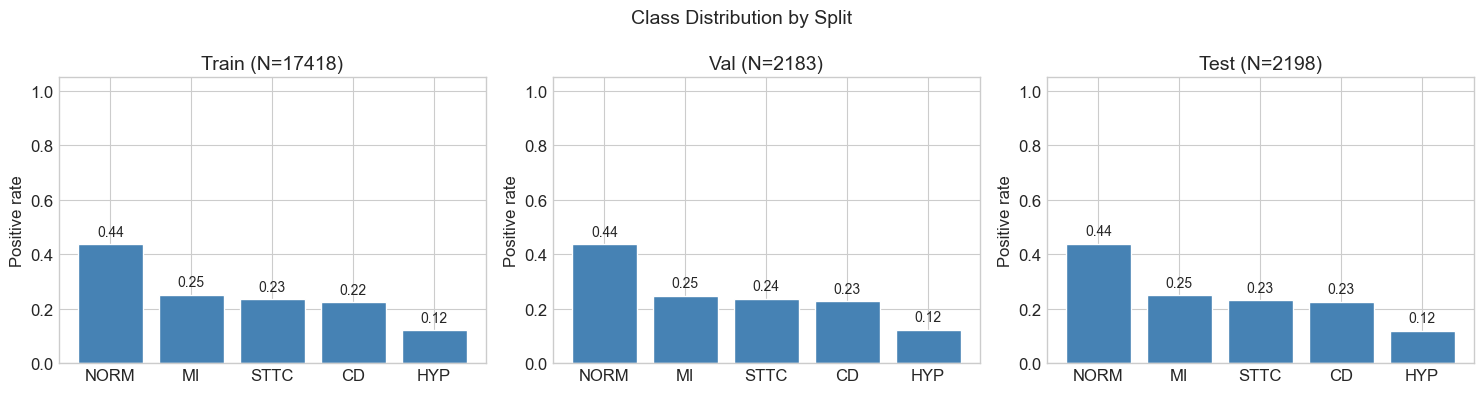

In [4]:
from data.dataset import PTBXLDataset
from data.preprocessing import (
    fit_normalizer, normalize, save_norm_stats, load_norm_stats,
    default_train_transforms,
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download PTB-XL+ from PhysioNet and place it in the project root."
    )

# ── Normalization stats ────────────────────────────────────────────
# Uses pre-computed stats from scripts/preprocess.py by default.
# Set use_precomputed=False to recompute (requires ~4 GB RAM).
use_precomputed = True
config_stats = PROJECT_ROOT / "config" / "norm_stats.npy"

if use_precomputed and config_stats.exists():
    mean, std = load_norm_stats(config_stats)
    print(f"Loaded pre-computed norm stats from {config_stats}")
else:
    print("Computing norm stats from training set (may take a while)…")
    _tmp_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE)
    _tmp_loader = DataLoader(_tmp_ds, batch_size=64, shuffle=False, num_workers=0)
    _X_list = []
    for _X, _ in tqdm(_tmp_loader, desc="Loading train signals"):
        _X_list.append(_X.numpy())
    _X_train = np.concatenate(_X_list, axis=0)   # (N, 12, L)
    mean, std = fit_normalizer(_X_train)
    del _X_train, _X_list
    print(f"Computed norm stats. mean.shape={mean.shape}")

save_norm_stats(mean, std, METRICS_DIR / f"{MODEL_NAME}_norm_stats.npy")
norm_stats = (mean, std)

# ── pos_weight ─────────────────────────────────────────────────────
pos_weight_path = PROJECT_ROOT / "data" / "processed" / "pos_weight.npy"
if not pos_weight_path.exists():
    raise FileNotFoundError(
        f"pos_weight.npy not found: {pos_weight_path}\n"
        "Run: python scripts/preprocess.py"
    )
pos_weight = torch.tensor(np.load(str(pos_weight_path)), dtype=torch.float32)
print(f"pos_weight: {pos_weight}")

# ── Datasets & DataLoaders ─────────────────────────────────────────
train_transform = default_train_transforms(signal_length=5000)

train_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE,
                         transform=train_transform, norm_stats=norm_stats)
val_ds   = PTBXLDataset(DATA_PATH, split="val",   sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)
test_ds  = PTBXLDataset(DATA_PATH, split="test",  sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)

print(f"\nSplit sizes → train:{len(train_ds)}, val:{len(val_ds)}, test:{len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")

X_s, y_s = next(iter(train_loader))
print(f"Batch shape → X:{X_s.shape}, y:{y_s.shape}")

# ── Class distribution bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (ds, title) in zip(axes, [(train_ds,"Train"),(val_ds,"Val"),(test_ds,"Test")]):
    labels = ds.get_all_labels()
    freqs  = labels.mean(axis=0)
    bars   = ax.bar(CLASS_NAMES, freqs, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} (N={len(ds)})")
    ax.set_ylabel("Positive rate")
    ax.set_ylim(0, 1.05)
    for bar, f in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{f:.2f}", ha="center", va="bottom", fontsize=10)
plt.suptitle("Class Distribution by Split", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 3 · Modelo

In [5]:
from models.patchtst import PatchTST

try:
    from torchinfo import summary as tinfo_summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("torchinfo not installed. pip install torchinfo")

model = PatchTST(
    n_classes=5, n_leads=12, signal_length=5000,
    patch_size=100, stride=50, d_model=128,
    n_heads=8, n_layers=4, ff_dim=512,
    attn_dropout=0.1, dropout=0.1,
).to(device)

if HAS_TORCHINFO:
    tinfo_summary(model, input_size=(BATCH_SIZE, 12, 5000),
                  col_names=["input_size","output_size","num_params","mult_adds"], depth=4)
else:
    n  = sum(p.numel() for p in model.parameters())
    nt = sum(p.numel() for p in model.parameters() if p.requires_grad)
    sz = sum(p.numel()*p.element_size() for p in model.parameters()) / 1e6
    print(f"Total params:     {n:,}")
    print(f"Trainable params: {nt:,}")
    print(f"Model size (MB):  {sz:.1f}")
    print(f"Patches per lead: {model.n_patches}")


C:\Personal\UP\ML2\ecg-classification\models\patchtst.py:123: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


## Celda 4 · Entrenamiento

In [4]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
scaler    = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

history = {"train_loss":[], "val_loss":[], "val_macro_auc":[], "val_macro_f1":[], "learning_rate":[]}
best_auc, best_epoch, patience_counter = 0.0, 0, 0
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
t0 = time.time()

for epoch in range(EPOCHS):
    # ── train ──────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for X, y in tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS} [train]", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        train_losses.append(loss.item())

    # ── validate ───────────────────────────────────────────────────
    model.eval()
    val_losses, vl, vt = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_losses.append(criterion(logits, y).item())
            vl.append(torch.sigmoid(logits).cpu())
            vt.append(y.cpu())

    vp = torch.cat(vl).numpy()
    vy = torch.cat(vt).numpy()
    val_auc = float(roc_auc_score(vy, vp, average="macro"))
    val_f1  = float(f1_score(vy, (vp >= 0.5).astype(int), average="macro", zero_division=0))

    history["train_loss"].append(float(np.mean(train_losses)))
    history["val_loss"].append(float(np.mean(val_losses)))
    history["val_macro_auc"].append(val_auc)
    history["val_macro_f1"].append(val_f1)
    history["learning_rate"].append(scheduler.get_last_lr()[0])
    scheduler.step()

    # ── checkpoint + early stopping ────────────────────────────────
    if val_auc > best_auc:
        best_auc, best_epoch, patience_counter = val_auc, epoch, 0
        torch.save({
            "epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auc": val_auc, "history": history,
        }, ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

    print(f"Ep {epoch+1:3d} | train={history['train_loss'][-1]:.4f} "
          f"| val={history['val_loss'][-1]:.4f} | auc={val_auc:.4f} | f1={val_f1:.4f}")

training_time_minutes = (time.time() - t0) / 60
# Attach training time to saved checkpoint
ckpt = torch.load(ckpt_path, map_location="cpu")
ckpt["training_time_minutes"] = training_time_minutes
torch.save(ckpt, ckpt_path)
print(f"\nBest val AUC={best_auc:.4f} @ epoch {best_epoch+1}")
print(f"Training time: {training_time_minutes:.1f} min | checkpoint → {ckpt_path}")


C:\Users\rodri\AppData\Local\Temp\ipykernel_48980\907278585.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Ep 1/100 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep   1 | train=0.8805 | val=0.7525 | auc=0.8474 | f1=0.6056


Ep 2/100 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep   2 | train=0.7082 | val=0.6871 | auc=0.8708 | f1=0.6415


...

Ep  74 | train=0.4153 | val=0.5651 | auc=0.9205 | f1=0.7153


Ep 75/100 [train]:   0%|          | 0/137 [00:00<?, ?it/s]

Ep  75 | train=0.4123 | val=0.5650 | auc=0.9199 | f1=0.7093


Ep 76/100 [train]:   0%|          | 0/137 [00:00<?, ?it/s]


Early stopping at epoch 76.

Best val AUC=0.9214 @ epoch 51
Training time: 122.1 min | checkpoint → C:\Personal\UP\ML2\ecg-classification\results\checkpoints\patchtst_best.pt


## Celda 5 · Evaluación — métricas completas

In [5]:
# ── Load best checkpoint ───────────────────────────────────────────
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
best_epoch = ckpt["epoch"]
training_time_minutes = ckpt.get("training_time_minutes", 0.0)
print(f"Loaded checkpoint  epoch={best_epoch+1}  val_auc={ckpt['val_auc']:.4f}")

# ── PASO 1: Optimal threshold per class on VAL set ─────────────────
model.eval()
vl, vt = [], []
with torch.no_grad():
    for X, y in tqdm(val_loader, desc="Val inference"):
        vl.append(torch.sigmoid(model(X.to(device))).cpu())
        vt.append(y.cpu())

val_proba = torch.cat(vl).numpy()
val_true  = torch.cat(vt).numpy()

thresholds = []
for i, cls in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.91, 0.01):
        pred = (val_proba[:, i] >= t).astype(int)
        f1   = f1_score(val_true[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    thresholds.append(best_t)
    print(f"  {cls}: threshold={best_t:.2f}  val_F1={best_f1:.4f}")

np.save(str(METRICS_DIR / f"{MODEL_NAME}_thresholds.npy"), np.array(thresholds))

# ── PASO 2: Test set inference ─────────────────────────────────────
tl, tt = [], []
with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Test inference"):
        tl.append(torch.sigmoid(model(X.to(device))).cpu())
        tt.append(y.cpu())

y_pred_proba  = torch.cat(tl).numpy()
y_true        = torch.cat(tt).numpy()
y_pred_binary = (y_pred_proba >= np.array(thresholds)).astype(int)

np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_true.npy"),        y_true)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_proba.npy"),  y_pred_proba)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_binary.npy"), y_pred_binary)

# ── PASO 3: Metrics ────────────────────────────────────────────────
macro_auc       = roc_auc_score(y_true, y_pred_proba, average="macro")
macro_f1        = f1_score(y_true, y_pred_binary, average="macro", zero_division=0)
macro_auprc     = average_precision_score(y_true, y_pred_proba, average="macro")
weighted_f1     = f1_score(y_true, y_pred_binary, average="weighted", zero_division=0)
accuracy        = accuracy_score(y_true.argmax(axis=1), y_pred_binary.argmax(axis=1))

auc_per_class       = roc_auc_score(y_true, y_pred_proba, average=None)
f1_per_class        = f1_score(y_true, y_pred_binary, average=None, zero_division=0)
precision_per_class = precision_score(y_true, y_pred_binary, average=None, zero_division=0)
recall_per_class    = recall_score(y_true, y_pred_binary, average=None, zero_division=0)
auprc_per_class     = average_precision_score(y_true, y_pred_proba, average=None)

specificity_per_class = []
for i in range(len(CLASS_NAMES)):
    tn, fp, fn, tp = confusion_matrix(
        y_true[:, i], y_pred_binary[:, i], labels=[0, 1]
    ).ravel()
    specificity_per_class.append(float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0)

n_params    = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

if device.type == "cuda":
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = []
    model.eval()
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            starter.record(); _ = model(X); ender.record()
            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender) / X.shape[0])
    inference_time_ms = float(np.mean(timings))
else:
    timings = []
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            t0_inf = time.perf_counter(); _ = model(X)
            timings.append((time.perf_counter() - t0_inf) / X.shape[0] * 1000)
    inference_time_ms = float(np.mean(timings))

# ── PASO 4: Save & print ───────────────────────────────────────────
metrics = {
    "model": MODEL_NAME, "macro_auc": float(macro_auc), "macro_f1": float(macro_f1),
    "macro_auprc": float(macro_auprc), "weighted_f1": float(weighted_f1),
    "accuracy": float(accuracy), "sensitivity": float(np.mean(recall_per_class)),
    "specificity": float(np.mean(specificity_per_class)),
    "n_params": int(n_params), "n_trainable": int(n_trainable),
    "inference_time_ms": inference_time_ms,
    "training_time_minutes": training_time_minutes,
    "auc_per_class":       [float(x) for x in auc_per_class],
    "f1_per_class":        [float(x) for x in f1_per_class],
    "precision_per_class": [float(x) for x in precision_per_class],
    "recall_per_class":    [float(x) for x in recall_per_class],
    "specificity_per_class": specificity_per_class,
    "auprc_per_class":     [float(x) for x in auprc_per_class],
    "optimal_threshold_per_class": thresholds,
}
with open(METRICS_DIR / f"{MODEL_NAME}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES, "AUC": auc_per_class, "F1": f1_per_class,
    "Precision": precision_per_class, "Recall": recall_per_class,
    "Specificity": specificity_per_class, "AUPRC": auprc_per_class,
    "Threshold": thresholds,
}).set_index("Class")
per_class_df.to_csv(METRICS_DIR / f"{MODEL_NAME}_metrics.csv")

print(f"\n{'='*55}")
print(f"  {MODEL_NAME.upper()} — Test Metrics")
print(f"{'='*55}")
print(f"  Macro AUC    : {macro_auc:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print(f"  Macro AUPRC  : {macro_auprc:.4f}")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Params       : {n_params:,}")
print(f"  Inference    : {inference_time_ms:.2f} ms/sample")
print(f"{'='*55}")
print(per_class_df.round(4).to_string())


Loaded checkpoint  epoch=51  val_auc=0.9214


Val inference:   0%|          | 0/18 [00:00<?, ?it/s]

  NORM: threshold=0.63  val_F1=0.8583
  MI: threshold=0.52  val_F1=0.7472
  STTC: threshold=0.77  val_F1=0.7498
  CD: threshold=0.76  val_F1=0.7215
  HYP: threshold=0.57  val_F1=0.5997


Test inference:   0%|          | 0/18 [00:00<?, ?it/s]


  PATCHTST — Test Metrics
  Macro AUC    : 0.9100
  Macro F1     : 0.7099
  Macro AUPRC  : 0.7728
  Weighted F1  : 0.7452
  Accuracy     : 0.7402
  Params       : 819,589
  Inference    : 0.71 ms/sample
          AUC      F1  Precision  Recall  Specificity   AUPRC  Threshold
Class                                                                   
NORM   0.9365  0.8475     0.8355  0.8598       0.8680  0.9019       0.63
MI     0.9120  0.7251     0.6816  0.7745       0.8792  0.7964       0.52
STTC   0.9268  0.7243     0.7118  0.7372       0.9108  0.7944       0.77
CD     0.8975  0.6832     0.6732  0.6935       0.9019  0.7845       0.76
HYP    0.8772  0.5696     0.4986  0.6641       0.9096  0.5870       0.57


## Celda 6 · Figura 1 — Curvas ROC

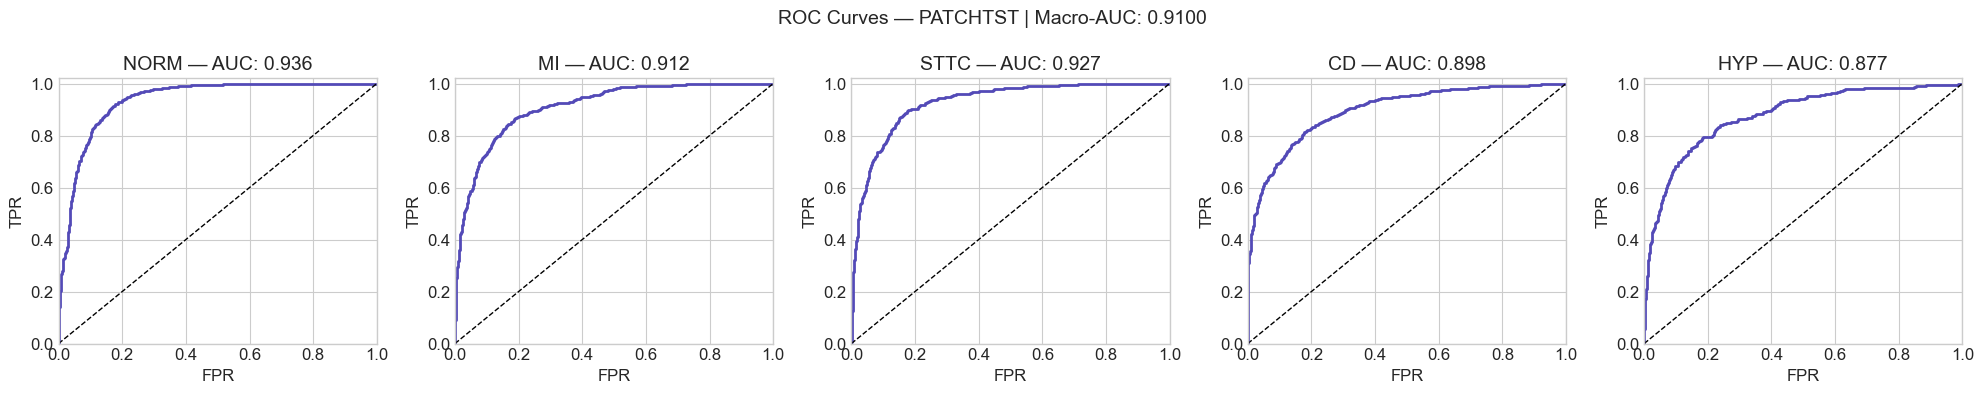

Saved ROC curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [6]:
# Figura 1 — Curvas ROC (1 fila × 5 subplots)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color="#534AB7")
    ax.plot([0,1], [0,1], "k--", lw=1)
    ax.set_title(f"{cls} — AUC: {auc_per_class[i]:.3f}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle(f"ROC Curves — {MODEL_NAME.upper()} | Macro-AUC: {macro_auc:.4f}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_roc_curves{ext}", **kw)
plt.show()
print(f"Saved ROC curves → {FIGURES_DIR}")


## Celda 7 · Figura 2 — Confusion Matrix

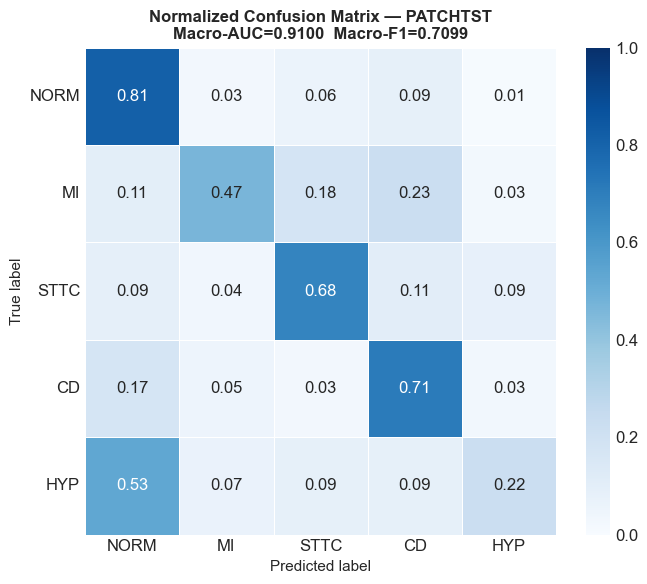

Saved confusion matrix → C:\Personal\UP\ML2\ecg-classification\results\figures


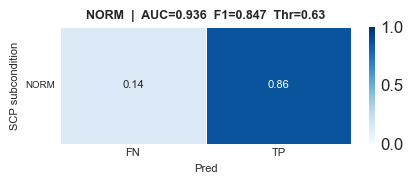

Saved → C:\Personal\UP\ML2\ecg-classification\results\figures\patchtst_confusion_NORM.png


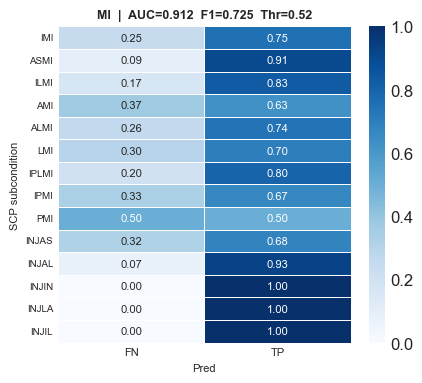

Saved → C:\Personal\UP\ML2\ecg-classification\results\figures\patchtst_confusion_MI.png


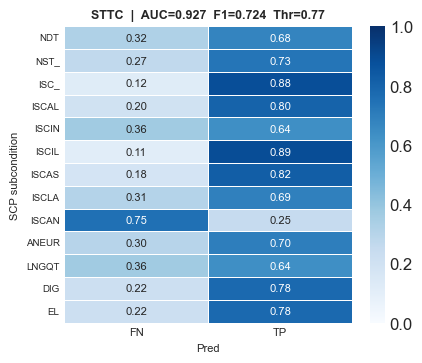

Saved → C:\Personal\UP\ML2\ecg-classification\results\figures\patchtst_confusion_STTC.png


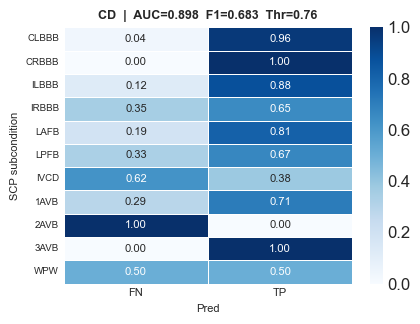

Saved → C:\Personal\UP\ML2\ecg-classification\results\figures\patchtst_confusion_CD.png


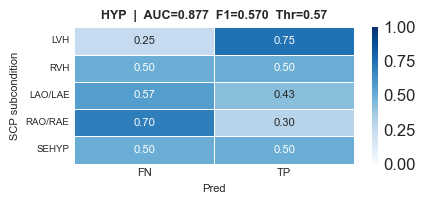

Saved → C:\Personal\UP\ML2\ecg-classification\results\figures\patchtst_confusion_HYP.png


In [10]:
# Figura 2a — Normalized Confusion Matrix (5×5)
y_true_cls = y_true.argmax(axis=1)
y_pred_cls = y_pred_proba.argmax(axis=1)

cm = confusion_matrix(y_true_cls, y_pred_cls, labels=list(range(len(CLASS_NAMES))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, cbar=True, linewidths=0.5, vmin=0, vmax=1,
    annot_kws={"size": 12},
)
ax.set_title(
    f"Normalized Confusion Matrix — {MODEL_NAME.upper()}\n"
    f"Macro-AUC={macro_auc:.4f}  Macro-F1={macro_f1:.4f}",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix{ext}", **kw)
plt.show()
print(f"Saved confusion matrix → {FIGURES_DIR}")

# ── Figura 2b — Por clase: subcondiciones SCP ──────────────────────
import ast

CLASS_CONDITIONS = {
    "NORM": ["NORM"],
    "MI":   ["IMI", "ASMI", "ILMI", "AMI", "ALMI", "LMI",
             "IPLMI", "IPMI", "PMI", "INJAS", "INJAL", "INJIN", "INJLA", "INJIL"],
    "STTC": ["NDT", "NST_", "ISC_", "ISCAL", "ISCIN", "ISCIL",
             "ISCAS", "ISCLA", "ISCAN", "ANEUR", "LNGQT", "DIG", "EL"],
    "CD":   ["CLBBB", "CRBBB", "ILBBB", "IRBBB", "LAFB", "LPFB",
             "IVCD", "1AVB", "2AVB", "3AVB", "WPW"],
    "HYP":  ["LVH", "RVH", "LAO/LAE", "RAO/RAE", "SEHYP"],
}

scp_df = pd.read_csv(DATA_PATH / "scp_statements.csv", index_col=0)
code_to_class_map = {
    code: str(row["diagnostic_class"]).strip()
    for code, row in scp_df.iterrows()
    if pd.notna(row.get("diagnostic_class", float("nan")))
}
meta_all  = pd.read_csv(DATA_PATH / "ptbxl_database.csv", index_col="ecg_id")
meta_test = meta_all[meta_all["strat_fold"] == 10].reset_index()

def parse_subconditions(scp_raw: str, target_cls: str) -> list:
    try:
        codes = ast.literal_eval(scp_raw)
    except (ValueError, SyntaxError):
        return []
    return [c for c, conf in codes.items()
            if conf > 0 and code_to_class_map.get(c) == target_cls]

CLASS_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}

for cls in CLASS_NAMES:
    conds = CLASS_CONDITIONS[cls]
    ci    = CLASS_IDX[cls]

    counts = {c: {0: 0, 1: 0} for c in conds}
    for sample_idx, (_, row_meta) in enumerate(meta_test.iterrows()):
        for sc in parse_subconditions(row_meta["scp_codes"], cls):
            if sc in counts:
                counts[sc][int(y_pred_binary[sample_idx, ci])] += 1

    df_pivot = pd.DataFrame(
        {"FN": [counts[c][0] for c in conds],
         "TP": [counts[c][1] for c in conds]},
        index=conds,
    )
    df_pivot = df_pivot[df_pivot.sum(axis=1) > 0]
    if df_pivot.empty:
        print(f"Sin datos para {cls}, saltando.")
        continue

    df_norm = df_pivot.div(df_pivot.sum(axis=1).replace(0, 1), axis=0)

    fig, ax = plt.subplots(figsize=(4.5, max(2.0, len(df_pivot) * 0.20 + 1.2)))
    sns.heatmap(df_norm, annot=True, fmt=".2f", cmap="Blues",
                ax=ax, cbar=True, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={"size": 8})
    ax.set_title(
        f"{cls}  |  AUC={auc_per_class[ci]:.3f}  F1={f1_per_class[ci]:.3f}  Thr={thresholds[ci]:.2f}",
        fontsize=9, fontweight="bold",
    )
    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("SCP subcondition", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=8)
    ax.yaxis.set_tick_params(rotation=0)
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
        plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_confusion_{cls}{ext}", **kw)
    plt.show()
    print(f"Saved → {FIGURES_DIR / f'{MODEL_NAME}_confusion_{cls}.png'}")

## Celda 8 · Figura 3 — Curvas de entrenamiento

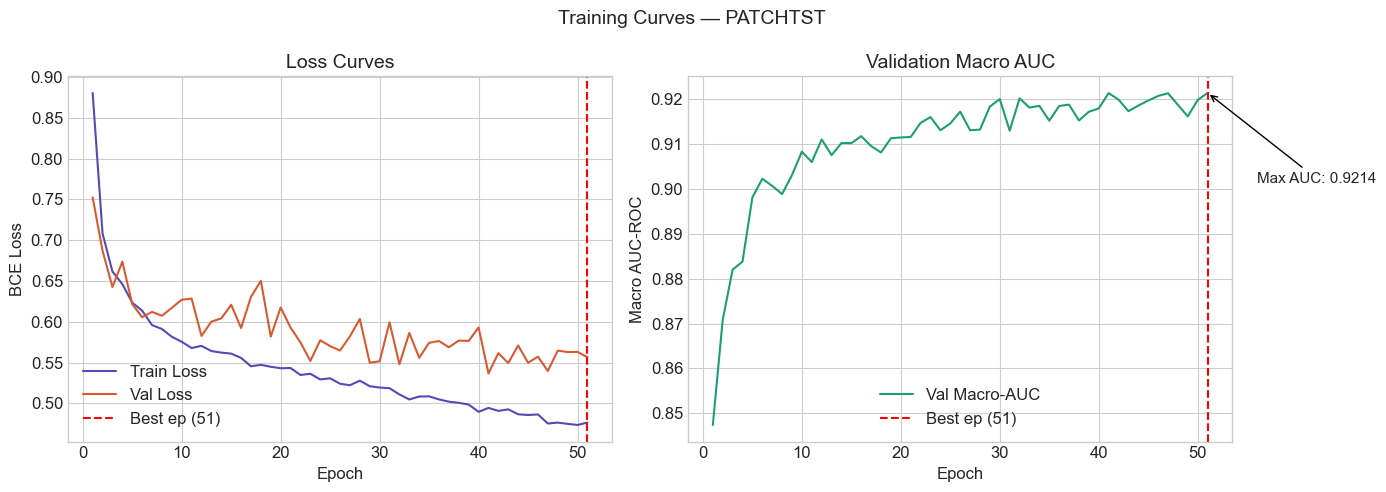

Saved training curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [8]:
# Figura 3 — Curvas de entrenamiento
epochs_r = range(1, len(history["train_loss"]) + 1)
best_ep  = ckpt["epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_r, history["train_loss"], label="Train Loss", color="#534AB7")
ax.plot(epochs_r, history["val_loss"],   label="Val Loss",   color="#D85A30")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Loss Curves"); ax.legend()

ax = axes[1]
ax.plot(epochs_r, history["val_macro_auc"], label="Val Macro-AUC", color="#1D9E75")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
best_val = history["val_macro_auc"][best_ep]
ax.annotate(f"Max AUC: {best_val:.4f}",
            xy=(best_ep+1, best_val), xytext=(best_ep+6, best_val-0.02),
            arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro AUC-ROC")
ax.set_title("Validation Macro AUC"); ax.legend()

plt.suptitle(f"Training Curves — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_training_curves{ext}", **kw)
plt.show()
print(f"Saved training curves → {FIGURES_DIR}")


## Celda 9 · Figura 4 — Curvas Precision-Recall

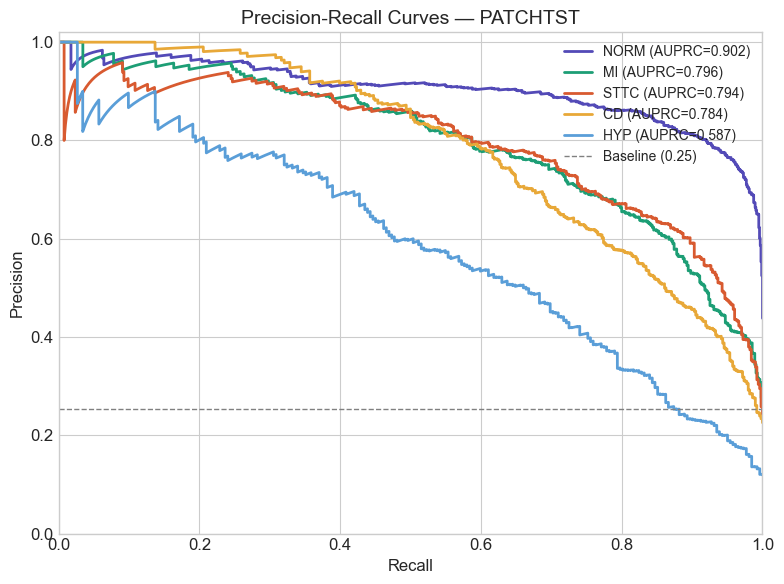

Saved PR curves → C:\Personal\UP\ML2\ecg-classification\results\figures


In [9]:
# Figura 4 — Curvas Precision-Recall
COLORS_5 = ["#534AB7", "#1D9E75", "#D85A30", "#E8A838", "#5A9ED8"]
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS_5)):
    prec, rec, _ = precision_recall_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(rec, prec, lw=2, label=f"{cls} (AUPRC={auprc_per_class[i]:.3f})", color=col)
baseline = y_true.mean()
ax.axhline(baseline, ls="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curves — {MODEL_NAME.upper()}")
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_pr_curves{ext}", **kw)
plt.show()
print(f"Saved PR curves → {FIGURES_DIR}")


## Celda 10 · Figura 5 — F1 y AUC por clase

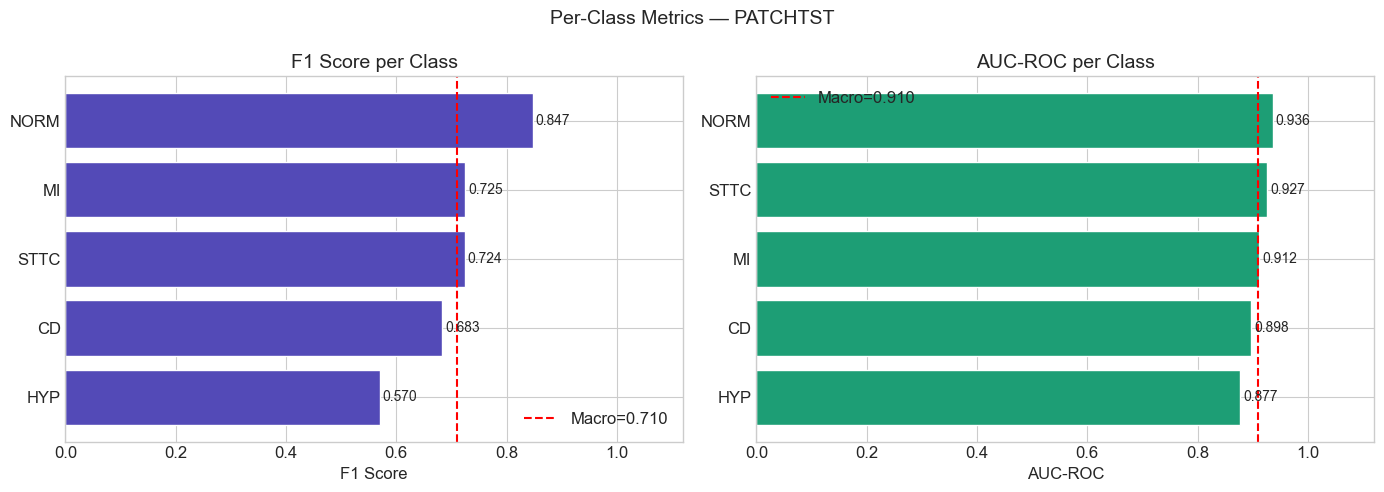

Saved per-class metrics → C:\Personal\UP\ML2\ecg-classification\results\figures


In [10]:
# Figura 5 — F1 y AUC por clase (barras horizontales)
f1_sorted  = sorted(zip(f1_per_class,  CLASS_NAMES), reverse=True)
auc_sorted = sorted(zip(auc_per_class, CLASS_NAMES), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sorted_data, macro_val, label, color in [
    (axes[0], f1_sorted,  macro_f1,  "F1 Score",  "#534AB7"),
    (axes[1], auc_sorted, macro_auc, "AUC-ROC",   "#1D9E75"),
]:
    vals, classes = zip(*sorted_data)
    bars = ax.barh(classes[::-1], vals[::-1], color=color, edgecolor="white")
    ax.axvline(macro_val, color="red", ls="--", lw=1.5, label=f"Macro={macro_val:.3f}")
    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10)
    ax.set_xlabel(label); ax.set_title(f"{label} per Class")
    ax.set_xlim([0, 1.12]); ax.legend()

plt.suptitle(f"Per-Class Metrics — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_per_class_metrics{ext}", **kw)
plt.show()
print(f"Saved per-class metrics → {FIGURES_DIR}")


# CELDA 11: Grad-CAM + Attention Maps 


<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
C:\Users\rodri\AppData\Local\Temp\ipykernel_42656\2310754175.py:8: SyntaxWarning: invalid escape sequence '\c'
  checkpoint_path = Path("../results\checkpoints\patchtst_best.pt")


Loaded best checkpoint: ..\results\checkpoints\patchtst_best.pt
Sample 100: NORM
Sample 250: NORM
Sample 500: STTC
Sample 1000: MI


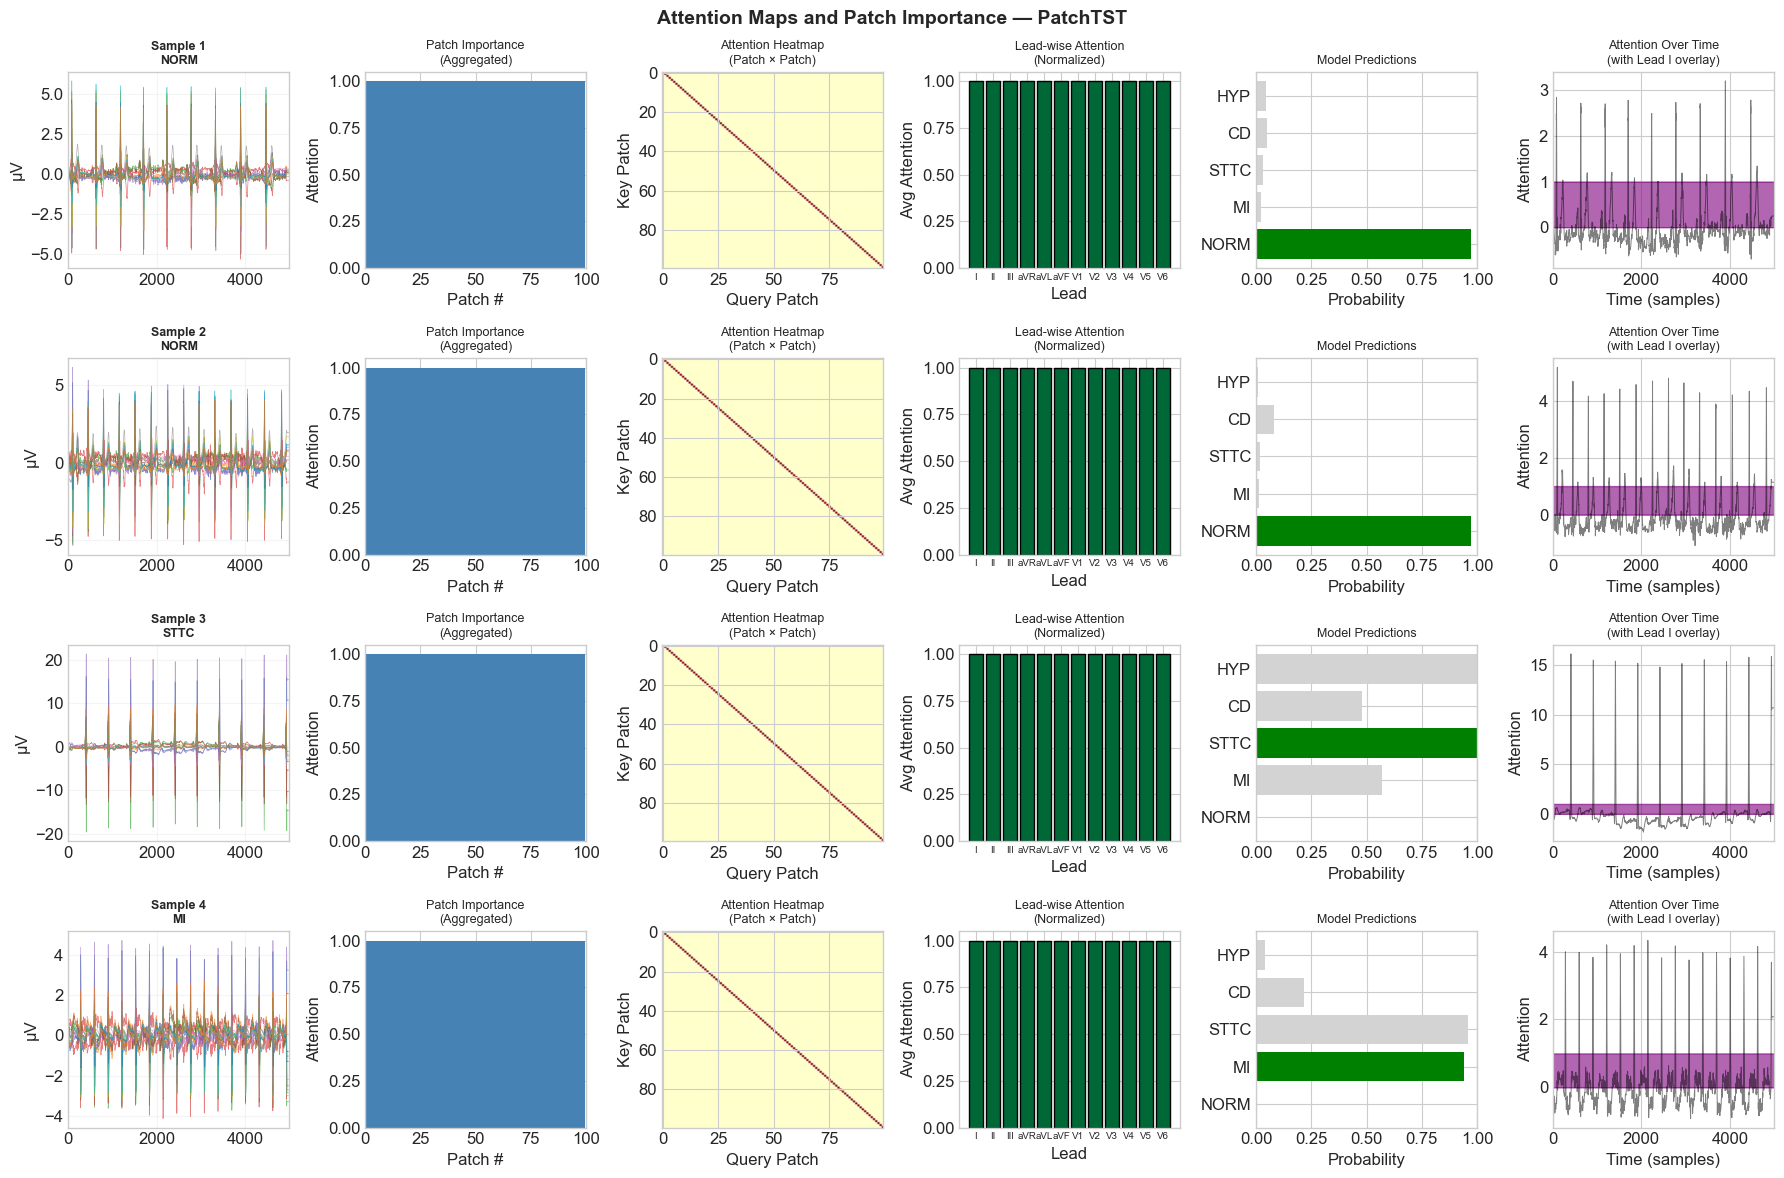


✓ Saved Attention Maps visualizations:
  - C:\Personal\UP\ML2\ecg-classification\results\figures\attention_maps_patchtst.png
  - C:\Personal\UP\ML2\ecg-classification\results\figures\attention_maps_patchtst.pdf


In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Load best model ────────────────────────────────────────────────────
checkpoint_path = Path("../results\checkpoints\patchtst_best.pt") 
checkpoint = torch.load(checkpoint_path, map_location=device)
state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", checkpoint))
model.load_state_dict(state_dict)
model.eval()
print(f"Loaded best checkpoint: {checkpoint_path}")

# ── Select 4 test samples ──────────────────────────────────────────────
test_indices = [100, 250, 500, 1000]
samples_data = []

for idx in test_indices:
    X, y = test_ds[idx]
    samples_data.append((X, y))
    print(f"Sample {idx}: {CLASS_NAMES[np.argmax(y.numpy())]}")

# ── Extract Attention Weights from PatchTST ───────────────────────────
def get_patchtst_attention(model, x, n_patches=100, n_leads=12):
    """Extract attention weights per lead and patch."""
    attention_weights = []
    
    def hook_fn(module, input, output):
        # If your MultiheadAttention module outputs weights, they are the second element
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            attention_weights.append(output[1])
    
    handles = []
    # ── FIXED LAYER PATH HERE ─────────────────────────────────────────
    for layer in model.encoder.layers:
        h = layer.self_attn.register_forward_hook(hook_fn)
        handles.append(h)
    
    # Optional patch: Force MultiheadAttention modules to output weights if they don't by default
    for layer in model.encoder.layers:
        layer.self_attn.need_weights = True
    
    with torch.no_grad():
        _ = model(x)
    
    for h in handles:
        h.remove()
    
    # Average across layers and batches
    if attention_weights:
        # attention_weights[0] shape is typically (batch_size, num_heads, seq_len, seq_len) 
        # or (batch, seq_len, seq_len) depending on PyTorch version/implementation
        attn_avg = torch.stack(attention_weights).mean(dim=0)[0]  
        if attn_avg.ndim == 3:  # If heads are still present: (heads, seq_len, seq_len)
            attn_avg = attn_avg.mean(dim=0)
        return attn_avg.cpu().numpy()
    else:
        print("Warning: No attention weights captured. Using identity matrix.")
        return np.eye(n_patches)

# ── Generate visualizations ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Attention Maps and Patch Importance — PatchTST", 
             fontsize=14, fontweight='bold')

PATCH_SIZE = 50  # samples per patch
N_PATCHES = 100

for idx, (x_sample, y_sample) in enumerate(samples_data):
    x_batch = x_sample.unsqueeze(0).to(device)
    
    # Prediction
    with torch.no_grad():
        logits = model(x_batch)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    gt_class = np.argmax(y_sample.numpy())
    gt_name = CLASS_NAMES[gt_class]
    
    # Get attention
    attn = get_patchtst_attention(model, x_batch)
    
    # ── Plot 1: Original signal (all 12 leads stacked) ──────────────────
    ax = plt.subplot(4, 6, idx*6 + 1)
    for lead in range(12):
        ax.plot(x_sample[lead].numpy(), linewidth=0.5, alpha=0.6)
    ax.set_title(f"Sample {idx+1}\n{gt_name}", fontsize=9, fontweight='bold')
    ax.set_ylabel("μV")
    ax.set_xlim([0, 5000])
    ax.grid(True, alpha=0.2)
    
    # ── Plot 2: Patch importance (aggregated across leads) ──────────────
    ax = plt.subplot(4, 6, idx*6 + 2)
    patch_importance = attn.sum(axis=0)  # Importance per patch
    patch_importance = patch_importance / patch_importance.max()
    
    ax.bar(range(N_PATCHES), patch_importance, color='steelblue', width=1)
    ax.set_title("Patch Importance\n(Aggregated)", fontsize=9)
    ax.set_xlabel("Patch #")
    ax.set_ylabel("Attention")
    ax.set_xlim([0, N_PATCHES])
    
    # ── Plot 3: Attention heatmap (patch-to-patch) ─────────────────────
    ax = plt.subplot(4, 6, idx*6 + 3)
    im = ax.imshow(attn, cmap='YlOrRd', aspect='auto')
    ax.set_title("Attention Heatmap\n(Patch × Patch)", fontsize=9)
    ax.set_xlabel("Query Patch")
    ax.set_ylabel("Key Patch")
    
    # ── Plot 4: Lead-wise attention ────────────────────────────────────
    ax = plt.subplot(4, 6, idx*6 + 4)
    lead_attention = np.zeros(12)
    for lead in range(12):
        # Calculate which patches correspond to high attention
        lead_patches = x_sample[lead].reshape(N_PATCHES, PATCH_SIZE)
        patch_imp = patch_importance
        lead_attention[lead] = patch_imp.mean()
    
    colors = plt.cm.RdYlGn(lead_attention / lead_attention.max())
    ax.bar(range(12), lead_attention, color=colors, edgecolor='black')
    ax.set_title("Lead-wise Attention\n(Normalized)", fontsize=9)
    ax.set_xlabel("Lead")
    ax.set_ylabel("Avg Attention")
    ax.set_xticks(range(12))
    ax.set_xticklabels(['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 
                        'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], fontsize=7)
    
    # ── Plot 5: Predictions ────────────────────────────────────────────
    ax = plt.subplot(4, 6, idx*6 + 5)
    colors_pred = ['green' if CLASS_NAMES[i] == gt_name else 'lightgray' 
                   for i in range(5)]
    ax.barh(CLASS_NAMES, probs, color=colors_pred)
    ax.set_title("Model Predictions", fontsize=9)
    ax.set_xlabel("Probability")
    ax.set_xlim([0, 1])
    
    # ── Plot 6: Attention to timepoints (aggregated) ────────────────────
    ax = plt.subplot(4, 6, idx*6 + 6)
    # Map patches back to time samples
    timepoint_attention = np.repeat(patch_importance, PATCH_SIZE)[:5000]
    ax.fill_between(range(5000), timepoint_attention, alpha=0.6, color='purple')
    ax.plot(x_sample[0].numpy(), linewidth=0.7, color='black', alpha=0.5)
    ax.set_title("Attention Over Time\n(with Lead I overlay)", fontsize=9)
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Attention")
    ax.set_xlim([0, 5000])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "attention_maps_patchtst.png", 
            dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / "attention_maps_patchtst.pdf", 
            bbox_inches='tight')
plt.show()

print(f"\n✓ Saved Attention Maps visualizations:")
print(f"  - {FIGURES_DIR / 'attention_maps_patchtst.png'}")
print(f"  - {FIGURES_DIR / 'attention_maps_patchtst.pdf'}")